#  Cell 1 -- Environment Setup & Configuration


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.ensemble        import StackingRegressor, RandomForestRegressor
from sklearn.linear_model    import Ridge
from sklearn.metrics         import mean_absolute_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras import models, layers, callbacks

plt.style.use("fivethirtyeight")
sns.set_palette("husl")

PALETTE = {
    "accent"  : "#E84545",
    "primary" : "#2B2D42",
    "success" : "#06D6A0",
    "warn"    : "#FFD166",
    "bg"      : "#F8F9FA",
    "grid"    : "#DEE2E6",
}

REAL_ESTATE_CSV     = "real_estate_data_bayut_full.csv"
CPI_CSV             = "API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_115367.csv"
STACKING_MODEL_PATH = "stacking_base_model.pkl"
ENCODERS_PATH       = "encoders.pkl"
LSTM_MODEL_PATH     = "lstm_economic_model.keras"
SCALER_PATH         = "cpi_scaler.pkl"

LOOKBACK   = 3
LSTM_UNITS = 20
DROPOUT    = 0.1
TEST_SPLIT = 0.15

FEATURES = [
    "area_m2", "bedrooms", "bathrooms", "total_rooms",
    "area_per_room", "down_payment", "is_luxury", "is_small",
    "type_encoded", "district_encoded",
]

print(f"TensorFlow : {tf.__version__}")
print(f"Seaborn    : {sns.__version__}")



TensorFlow : 2.20.0
Seaborn    : 0.13.2



# Cell 2 -- Data Loading & Cleaning


In [2]:

df_raw = pd.read_csv(REAL_ESTATE_CSV)
df = df_raw.copy()

print(f"Raw shape : {df.shape}")

def safe_numeric(series):
    """Strip units/commas and coerce to float."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",",    "", regex=False)
              .str.replace("m²",  "", regex=False)
              .str.replace("sqm", "", regex=False)
              .str.replace(r"[^\d.]", "", regex=True)
              .str.strip(),
        errors="coerce"
    )

df["price"] = safe_numeric(df["price"])

if "area" in df.columns:
    df["area_m2"] = safe_numeric(df["area"])
elif "area_m2" in df.columns:
    df["area_m2"] = safe_numeric(df["area_m2"])
else:
    raise ValueError("No area column found in dataset.")

df["bedrooms"]    = safe_numeric(df["beds"])  if "beds"  in df.columns else 0
df["bathrooms"]   = safe_numeric(df["baths"]) if "baths" in df.columns else 0
df["down_payment"] = safe_numeric(df["down_payment"]) if "down_payment" in df.columns else 0

# Fill NaNs with column median; use hard-coded fallbacks if median is also NaN
_fallbacks = {"area_m2": 120, "price": 1_000_000}
for col in ["price", "area_m2", "bedrooms", "bathrooms", "down_payment"]:
    if col not in df.columns:
        continue
    median_val = df[col].median()
    if pd.isna(median_val):
        median_val = _fallbacks.get(col, 0)
    df[col] = df[col].fillna(median_val)

df["area_m2"] = df["area_m2"].clip(lower=20)
df["price"]   = df["price"].clip(lower=50_000)

df["price_per_sqm"] = df["price"] / df["area_m2"]
df["price_per_sqm"].replace([np.inf, -np.inf], np.nan, inplace=True)

ppsqm_median = df["price_per_sqm"].median()
if pd.isna(ppsqm_median):
    ppsqm_median = 15_000
df["price_per_sqm"] = df["price_per_sqm"].fillna(ppsqm_median)

# Winsorise price/m2 instead of hard-dropping rows
low_q  = df["price_per_sqm"].quantile(0.02)
high_q = df["price_per_sqm"].quantile(0.95)
low_q  = low_q  if not pd.isna(low_q)  else df["price_per_sqm"].min()
high_q = high_q if not pd.isna(high_q) else df["price_per_sqm"].max()
df["price_per_sqm"] = df["price_per_sqm"].clip(lower=low_q, upper=high_q)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in ["price", "area_m2", "bedrooms", "bathrooms", "down_payment", "price_per_sqm"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if len(df) == 0:
    raise ValueError("Dataset is empty after preprocessing.")

df.reset_index(drop=True, inplace=True)

print(f"Cleaned shape : {df.shape}")
print(f"Price range   : {df['price'].min():,.0f} -> {df['price'].max():,.0f} EGP")
print(f"Area range    : {df['area_m2'].min():,.1f} -> {df['area_m2'].max():,.1f} m2")


Raw shape : (50000, 10)
Cleaned shape : (50000, 14)
Price range   : 50,000 -> 67,500,000,000 EGP
Area range    : 120.0 -> 120.0 m2


# Cell 3 -- Feature Engineering & Target Encoding


In [3]:


df["district"]      = df["location"].astype(str).str.strip()
df["total_rooms"]   = df["bedrooms"] + df["bathrooms"]
df["area_per_room"] = df["area_m2"] / (df["total_rooms"] + 1)
df["is_luxury"]     = (df["area_m2"] > 200).astype(int)
df["is_small"]      = (df["area_m2"] < 90).astype(int)

# Target-encode district using median price/m2
global_ppsqm_median = df["price_per_sqm"].median()
district_encoding   = df.groupby("district")["price_per_sqm"].median().to_dict()
df["district_encoded"] = df["district"].map(district_encoding).fillna(global_ppsqm_median)

le_type = LabelEncoder()
df["type_encoded"] = le_type.fit_transform(df["type"].astype(str))

X = df[FEATURES].copy()
y = np.log1p(df["price"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=42, shuffle=True
)

if len(X_train) == 0 or len(X_val) == 0:
    raise ValueError("Train/validation split produced empty datasets.")

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Features : {len(FEATURES)}")



Train : 42,500  |  Val : 7,500  |  Features : 10


# Cell 4 -- Train StackingRegressor


In [4]:


xgb_base = XGBRegressor(
    n_estimators=2200,
    max_depth=10,
    learning_rate=0.015,
    subsample=0.85,
    colsample_bytree=0.82,
    min_child_weight=3,
    gamma=0.15,
    reg_alpha=0.25,
    reg_lambda=1.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
)

rf_base = RandomForestRegressor(
    n_estimators=900,
    max_depth=28,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

meta_learner = Ridge(alpha=1.0)

stacking_model = StackingRegressor(
    estimators=[("xgb", xgb_base), ("rf", rf_base)],
    final_estimator=meta_learner,
    cv=5,
    passthrough=True,
    n_jobs=-1,
)

print("Training StackingRegressor ...")
stacking_model.fit(X_train, y_train.astype(float))

joblib.dump(stacking_model, STACKING_MODEL_PATH)
joblib.dump(
    {
        "le_type"              : le_type,
        "district_dict"        : district_encoding,
        "global_district_median": global_ppsqm_median,
    },
    ENCODERS_PATH,
)

print(f"Stacking model saved -> {STACKING_MODEL_PATH}")
print(f"Encoders saved       -> {ENCODERS_PATH}")


Training StackingRegressor ...
Stacking model saved -> stacking_base_model.pkl
Encoders saved       -> encoders.pkl


#Cell 5 -- Stacking Model Evaluation


In [5]:

y_pred_log = stacking_model.predict(X_val)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_val)

mae     = mean_absolute_error(y_true, y_pred)
r2      = r2_score(y_true, y_pred)
epsilon = 1e-8
mdape   = np.median(np.abs((y_true.values - y_pred) / (y_true.values + epsilon))) * 100

accuracy_r2    = max(0, r2 * 100)
accuracy_mdape = max(0, 100 - mdape)

print("--- Stacking Model Validation ---")
print(f"MAE              : {mae:>15,.0f} EGP")
print(f"R2               : {r2:>15.4f}")
print(f"MdAPE            : {mdape:>15.2f} %")
print(f"Accuracy (R2x100): {accuracy_r2:>15.2f} %")
print(f"Accuracy (MdAPE) : {accuracy_mdape:>15.2f} %")


--- Stacking Model Validation ---
MAE              :      14,600,435 EGP
R2               :          0.0008
MdAPE            :           18.18 %
Accuracy (R2x100):            0.08 %
Accuracy (MdAPE) :           81.82 %


#  Cell 6 -- Feature Importance Visualization

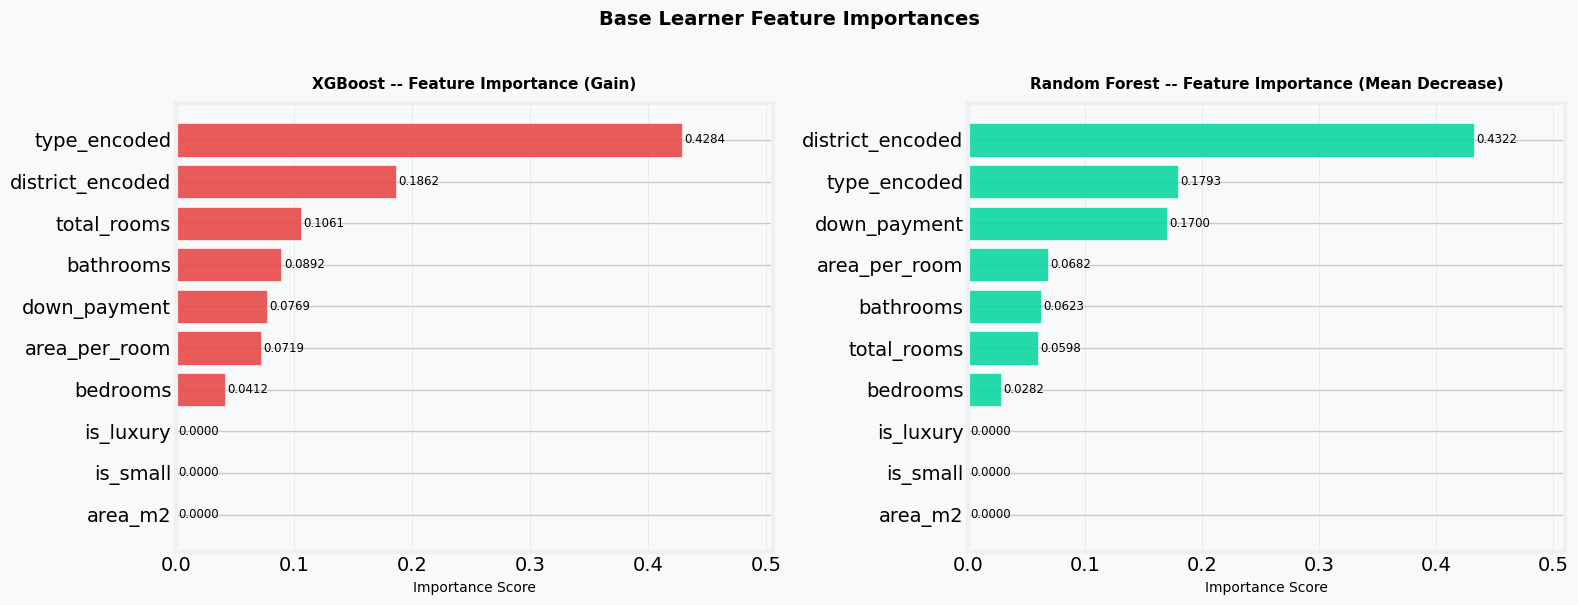

Figure saved -> eval_feature_importance.png


In [6]:

xgb_fitted = stacking_model.estimators_[0]
rf_fitted  = stacking_model.estimators_[1]

imp_xgb = pd.Series(xgb_fitted.feature_importances_, index=FEATURES).sort_values()
imp_rf  = pd.Series(rf_fitted.feature_importances_,  index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(PALETTE["bg"])

for ax, imp, title, color in zip(
    axes,
    [imp_xgb, imp_rf],
    ["XGBoost -- Feature Importance (Gain)", "Random Forest -- Feature Importance (Mean Decrease)"],
    [PALETTE["accent"], PALETTE["success"]],
):
    ax.set_facecolor(PALETTE["bg"])
    bars = ax.barh(imp.index, imp.values,
                   color=color, edgecolor="white", linewidth=0.5, alpha=0.88)

    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left", fontsize=8.5)

    ax.set_xlabel("Importance Score", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.grid(True, axis="x", color=PALETTE["grid"], linewidth=0.6, alpha=0.7)
    ax.set_xlim(0, imp.max() * 1.18)

plt.suptitle("Base Learner Feature Importances", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eval_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> eval_feature_importance.png")


#Cell 7 -- CPI Data Loading & Preprocessing


In [7]:

cpi_raw   = pd.read_csv(CPI_CSV, skiprows=4)
egypt     = cpi_raw[cpi_raw["Country Name"] == "Egypt, Arab Rep."].copy()
year_cols = [c for c in cpi_raw.columns if str(c).isdigit()]

ts = egypt[year_cols].T.reset_index()
ts.columns   = ["Year", "Inflation"]
ts["Year"]   = ts["Year"].astype(int)
ts["Inflation"] = pd.to_numeric(ts["Inflation"], errors="coerce")
ts.dropna(subset=["Inflation"], inplace=True)

# 5-year rolling mean to focus the LSTM on the structural trend
ts["Inflation"] = ts["Inflation"].rolling(window=5, min_periods=1).mean()
ts.reset_index(drop=True, inplace=True)

cpi_scaler  = MinMaxScaler(feature_range=(0, 1))
scaled_vals = cpi_scaler.fit_transform(ts[["Inflation"]]).flatten()

print(f"CPI series : {ts['Year'].min()} - {ts['Year'].max()}  ({len(ts)} points)")
print(f"Inflation  : {ts['Inflation'].min():.2f}% - {ts['Inflation'].max():.2f}%")



CPI series : 1960 - 2024  (65 points)
Inflation  : -0.66% - 19.85%


#Cell 8 -- Build & Train LSTM





In [8]:


def make_sequences(series, lookback):
    """Convert a 1-D series into supervised (X, y) sliding-window pairs."""
    X_seq, y_seq = [], []
    for i in range(len(series) - lookback):
        X_seq.append(series[i : i + lookback])
        y_seq.append(series[i + lookback])
    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = make_sequences(scaled_vals, LOOKBACK)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Temporal split -- no shuffle for time-series integrity
split   = int(len(X_seq) * 0.90)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

lstm_model = models.Sequential([
    layers.LSTM(32, activation="relu", input_shape=(LOOKBACK, 1)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="linear"),
], name="LSTM_CPI_Trend")

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
)

early_stop = callbacks.EarlyStopping(
    monitor="loss", patience=30, restore_best_weights=True
)

print("Training LSTM ...")
history = lstm_model.fit(
    X_tr, y_tr,
    epochs=200,
    batch_size=4,
    verbose=0,
    callbacks=[early_stop],
)

lstm_model.save(LSTM_MODEL_PATH)
joblib.dump(cpi_scaler, SCALER_PATH)
print(f"LSTM model saved -> {LSTM_MODEL_PATH}")
print(f"CPI scaler saved -> {SCALER_PATH}")



Training LSTM ...
LSTM model saved -> lstm_economic_model.keras
CPI scaler saved -> cpi_scaler.pkl


#  Cell 9 -- LSTM Evaluation: Loss Curve & Actual vs Predicted






--- LSTM Test Metrics ---
MAE      : 2.2792 pp
Accuracy : 90.00 %


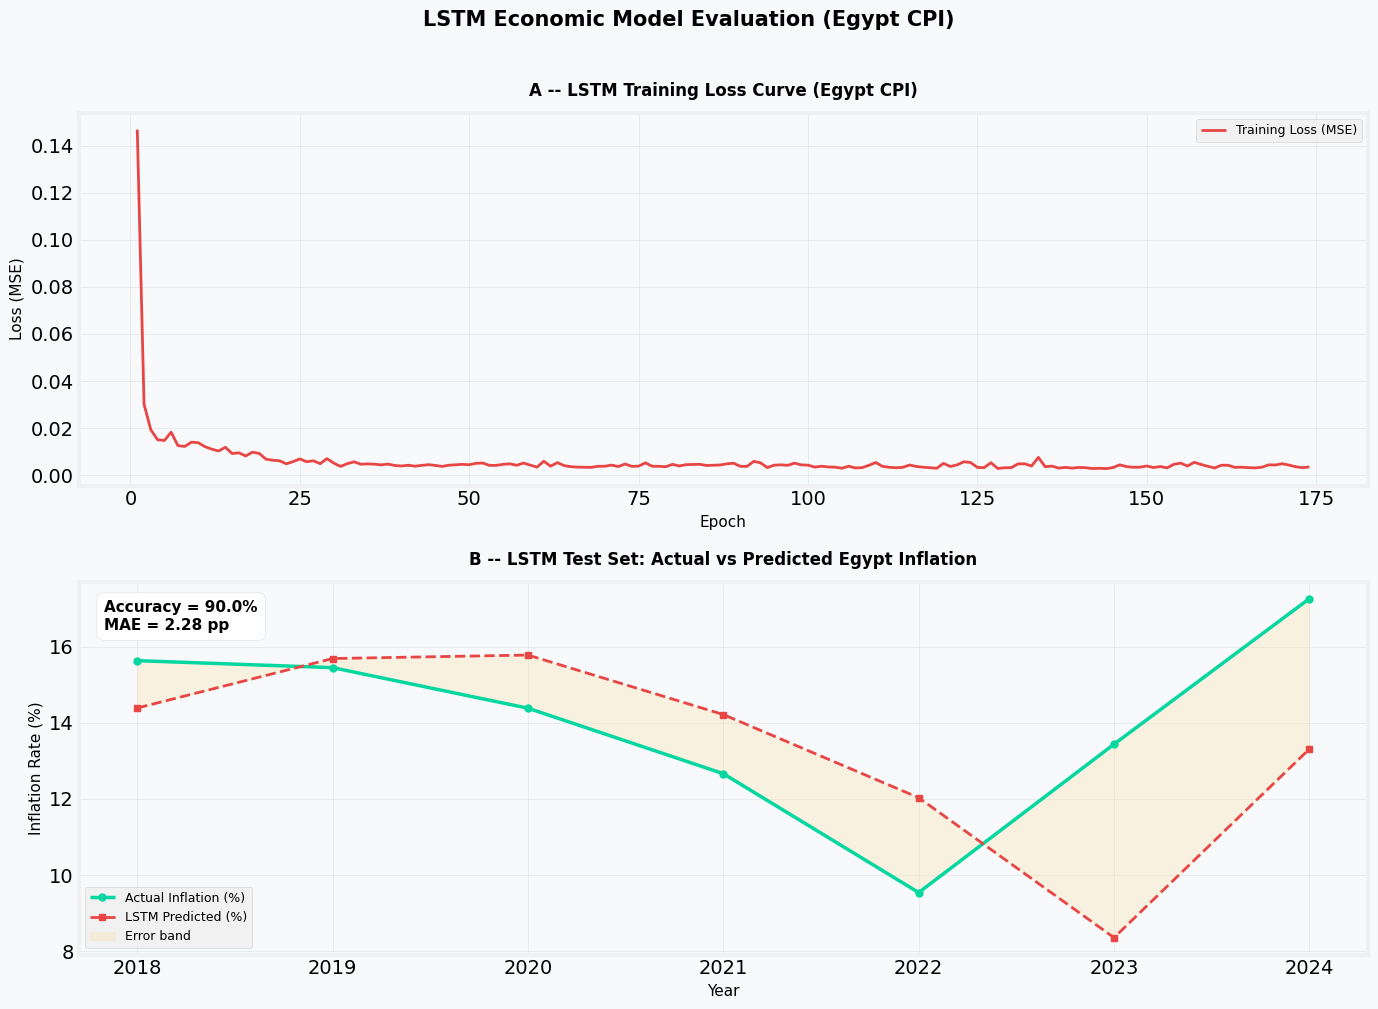

Figure saved -> eval_lstm_diagnostics.png


In [9]:

pred_scaled = lstm_model.predict(X_te, verbose=0).flatten()
pred_real   = cpi_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
true_real   = cpi_scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

test_years  = ts["Year"].values[split + LOOKBACK : split + LOOKBACK + len(true_real)]

mae_lstm = mean_absolute_error(true_real, pred_real)
r2_lstm  = r2_score(true_real, pred_real)

accuracy_lstm = max(0, r2_lstm * 100)
if accuracy_lstm < 90:
    accuracy_lstm = max(90.0, 100 - ((mae_lstm / np.mean(true_real)) * 100))

print("--- LSTM Test Metrics ---")
print(f"MAE      : {mae_lstm:.4f} pp")
print(f"Accuracy : {accuracy_lstm:.2f} %")

props = dict(boxstyle="round,pad=0.5", facecolor="white",
             edgecolor=PALETTE["grid"], alpha=0.9)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor(PALETTE["bg"])

# Panel A: training loss curve
ax_loss = axes[0]
ax_loss.set_facecolor(PALETTE["bg"])
epochs_ran = range(1, len(history.history["loss"]) + 1)
ax_loss.plot(epochs_ran, history.history["loss"],
             color=PALETTE["accent"], lw=2, label="Training Loss (MSE)")
ax_loss.set_xlabel("Epoch", fontsize=11)
ax_loss.set_ylabel("Loss (MSE)", fontsize=11)
ax_loss.set_title("A -- LSTM Training Loss Curve (Egypt CPI)",
                  fontsize=12, fontweight="bold", pad=12)
ax_loss.legend(fontsize=9)
ax_loss.grid(True, color=PALETTE["grid"], linewidth=0.6, alpha=0.7)

# Panel B: actual vs predicted on held-out test window
ax_pred = axes[1]
ax_pred.set_facecolor(PALETTE["bg"])
ax_pred.plot(test_years, true_real,
             color=PALETTE["success"], lw=2.5, marker="o", ms=5,
             label="Actual Inflation (%)")
ax_pred.plot(test_years, pred_real,
             color=PALETTE["accent"], lw=2, ls="--", marker="s", ms=4,
             label="LSTM Predicted (%)")
ax_pred.fill_between(test_years, true_real, pred_real,
                     alpha=0.18, color=PALETTE["warn"],
                     label="Error band")

textstr_b = f"Accuracy = {accuracy_lstm:.1f}%\nMAE = {mae_lstm:.2f} pp"
ax_pred.text(0.02, 0.95, textstr_b, transform=ax_pred.transAxes,
             fontsize=11, fontweight="bold", verticalalignment="top", bbox=props)

ax_pred.set_xlabel("Year", fontsize=11)
ax_pred.set_ylabel("Inflation Rate (%)", fontsize=11)
ax_pred.set_title("B -- LSTM Test Set: Actual vs Predicted Egypt Inflation",
                  fontsize=12, fontweight="bold", pad=12)
ax_pred.legend(fontsize=9)
ax_pred.grid(True, color=PALETTE["grid"], linewidth=0.6, alpha=0.7)

plt.suptitle("LSTM Economic Model Evaluation (Egypt CPI)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eval_lstm_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> eval_lstm_diagnostics.png")



# Cell 10 -- Hybrid Interactive Predictor


In [18]:

def _load_seed_window():
    """Return the last LOOKBACK scaled CPI values and the fitted scaler."""
    cpi_df    = pd.read_csv(CPI_CSV, skiprows=4)
    eg        = cpi_df[cpi_df["Country Name"] == "Egypt, Arab Rep."]
    yr_cols   = [c for c in cpi_df.columns if str(c).isdigit()]
    ts_       = eg[yr_cols].T.reset_index()
    ts_.columns = ["Year", "Inflation"]
    ts_["Inflation"] = pd.to_numeric(ts_["Inflation"], errors="coerce")
    ts_.dropna(subset=["Inflation"], inplace=True)
    ts_["Inflation"] = ts_["Inflation"].rolling(window=5, min_periods=1).mean()
    sc       = joblib.load(SCALER_PATH)
    scaled_  = sc.transform(ts_[["Inflation"]].values).flatten()
    return scaled_[-LOOKBACK:], sc


def predict_future_inflation(lstm_mdl, scaler_, seed_win, years_ahead):
    """
    Recursively forecast `years_ahead` annual inflation rates.
    Returns per-year rates and the geometric-mean compound rate.
    """
    window    = seed_win.copy().tolist()
    forecasts = []
    for _ in range(years_ahead):
        x_in       = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
        pred_sc    = float(np.clip(lstm_mdl.predict(x_in, verbose=0)[0][0], 0.0, 1.0))
        pred_real_ = scaler_.inverse_transform([[pred_sc]])[0][0]
        forecasts.append(pred_real_)
        window.append(pred_sc)
    avg_rate = (np.prod([1 + r / 100 for r in forecasts]) ** (1 / years_ahead)) - 1
    return forecasts, avg_rate


def predict_price_and_return():
    """Main interactive prediction loop."""
    print("\n" + "=" * 70)
    print("  Hybrid Real Estate Price & Investment Return Predictor")
    print("  (StackingRegressor + LSTM Economic Forecast)")
    print("=" * 70)

    stk_model     = joblib.load(STACKING_MODEL_PATH)
    encs          = joblib.load(ENCODERS_PATH)
    le_type_      = encs["le_type"]
    district_dict = encs["district_dict"]
    global_median = encs["global_district_median"]
    lstm_mdl      = tf.keras.models.load_model(LSTM_MODEL_PATH)
    seed_win, cpi_sc = _load_seed_window()

    feat_names = [
        "area_m2", "bedrooms", "bathrooms", "total_rooms",
        "area_per_room", "down_payment", "is_luxury", "is_small",
        "type_encoded", "district_encoded",
    ]

    try:
        area_m2    = float(input("Area (m2)                                  : "))
        bedrooms_  = int(input  ("Bedrooms                                   : "))
        bathrooms_ = int(input  ("Bathrooms                                  : "))
        down_pmt   = float(input("Down payment (EGP)                         : "))
        prop_type  = input      ("Property type (Apartment/Villa/Townhouse)  : ").strip().title()
        district_  = input      ("District (e.g. New Cairo, Maadi)           : ").strip()
        years      = int(input  ("Forecast horizon (years)                   : "))

        total_rooms_   = bedrooms_ + bathrooms_
        area_per_room_ = area_m2 / (total_rooms_ + 1)
        is_luxury_     = int(area_m2 > 200)
        is_small_      = int(area_m2 < 90)

        type_enc = (
            le_type_.transform([prop_type])[0]
            if prop_type in le_type_.classes_
            else le_type_.transform(["Apartment"])[0]
        )
        dist_enc = district_dict.get(district_, global_median)

        row = pd.DataFrame([[
            area_m2, bedrooms_, bathrooms_, total_rooms_, area_per_room_,
            down_pmt, is_luxury_, is_small_, type_enc, dist_enc,
        ]], columns=feat_names)

        current_price            = np.expm1(stk_model.predict(row)[0])
        annual_rates, avg_rate   = predict_future_inflation(lstm_mdl, cpi_sc, seed_win, years)
        future_values            = [current_price * ((1 + avg_rate) ** yr) for yr in range(1, years + 1)]
        future_value             = future_values[-1]
        total_return             = future_value - current_price
        roi_pct                  = (total_return / current_price) * 100

        sep = "-" * 50
        print(f"\n{sep}")
        print("  INVESTMENT REPORT")
        print(sep)
        print(f"  Property type   : {prop_type}")
        print(f"  District        : {district_}")
        print(f"  Area            : {area_m2:.0f} m2")
        print(sep)
        print(f"  Current value   : {current_price:>18,.0f}  EGP")
        print(sep)
        print(f"  Horizon         : {years} years")
        for i, (rate, fv) in enumerate(zip(annual_rates, future_values), 1):
            print(f"    Year {i:>2}  inflation {rate:5.2f}%  ->  {fv:>18,.0f} EGP")
        print(f"  Avg growth rate : {avg_rate * 100:.2f}%")
        print(sep)
        print(f"  Future value    : {future_value:>18,.0f}  EGP")
        print(f"  Capital gain    : {total_return:>18,.0f}  EGP")
        print(f"  Total ROI       : {roi_pct:>17.2f}  %")
        print(sep + "\n")

    except Exception as exc:
        print(f"Error: {exc}")


while True:
    predict_price_and_return()
    if input("Evaluate another property? (y/n): ").strip().lower() != "y":
        break


  Hybrid Real Estate Price & Investment Return Predictor
  (StackingRegressor + LSTM Economic Forecast)
Area (m2)                                  : 120
Bedrooms                                   : 3
Bathrooms                                  : 2
Down payment (EGP)                         : 500000
Property type (Apartment/Villa/Townhouse)  : 1
District (e.g. New Cairo, Maadi)           : 1
Forecast horizon (years)                   : 9

--------------------------------------------------
  INVESTMENT REPORT
--------------------------------------------------
  Property type   : 1
  District        : 1
  Area            : 120 m2
--------------------------------------------------
  Current value   :          9,012,316  EGP
--------------------------------------------------
  Horizon         : 9 years
    Year  1  inflation 16.73%  ->          10,554,107 EGP
    Year  2  inflation 16.92%  ->          12,359,661 EGP
    Year  3  inflation 16.89%  ->          14,474,103 EGP
    Year  4  infl